<a href="https://colab.research.google.com/github/aabedaaiyyub/aabedaaiyyub.github.io/blob/main/Untitled8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import io

In [ ]:
# This will open a file picker dialog for you to select your Excel file
uploaded = files.upload()

# Assuming you upload a single file, get its name
file_name = next(iter(uploaded))

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

Saving cancer.xlsx to cancer (2).xlsx


In [ ]:
display(df)

,ID,TRT,AGE,WEIGHIN,STAGE,TOTALCIN,TOTALCW2,TOTALCW4,TOTALCW6
0,1,0,52,124.0,2,6,6,6,7
1,5,0,77,160.0,1,9,6,10,9
2,6,0,60,136.5,4,7,9,17,19
3,9,0,61,179.6,1,6,7,9,3
4,11,0,59,175.8,2,6,7,16,13
5,15,0,69,167.6,1,6,6,6,11
6,21,0,67,186.0,1,6,11,11,10
7,26,0,56,158.0,3,6,11,15,15
8,31,0,61,212.8,1,6,9,6,8
9,35,0,51,189.0,1,6,4,8,7


In [ ]:
df.describe()

,ID,TRT,AGE,WEIGHIN,STAGE,TOTALCIN,TOTALCW2,TOTALCW4,TOTALCW6
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,23.826087,0.391304,59.043478,178.760870,1.956522,6.478261,8.173913,9.869565,9.478261
std,15.735461,0.499011,13.189108,33.248605,1.223938,1.562910,2.587596,3.166649,3.488547
min,1.000000,0.000000,27.000000,124.000000,1.000000,4.000000,4.000000,6.000000,3.000000
25%,11.500000,0.000000,51.500000,159.000000,1.000000,6.000000,6.500000,7.500000,7.000000
50%,22.000000,0.000000,60.000000,172.800000,1.000000,6.000000,7.000000,9.000000,9.000000
75%,36.000000,1.000000,67.000000,188.000000,2.500000,7.000000,9.500000,11.000000,11.000000
max,58.000000,1.000000,86.000000,261.400000,4.000000,12.000000,16.000000,17.000000,19.000000


In [ ]:
from scipy import stats

# Split data by treatment
group0 = df[df['TRT'] == 0]['TOTALCW6']
group1 = df[df['TRT'] == 1]['TOTALCW6']

# Independent T-Test (comparing final oral condition between groups)
t_stat, p_val = stats.ttest_ind(group0, group1)

print(f"--- Independent T-Test (TOTALCW6) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}\n")

--- Independent T-Test (TOTALCW6) ---
T-statistic: 0.7648
P-value: 0.4529



In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Create df_long by "melting" the wide columns into rows
df_long = pd.melt(df,
                  id_vars=['ID', 'TRT', 'AGE', 'WEIGHIN', 'STAGE'],
                  value_vars=['TOTALCIN', 'TOTALCW2', 'TOTALCW4', 'TOTALCW6'],
                  var_name='Time',
                  value_name='OralCondition')

# 2. Run the Mixed Effects Model
# This treats 'Time' and 'TRT' as factors and 'ID' as the random grouping variable
md = smf.mixedlm("OralCondition ~ Time * TRT", df_long, groups=df_long["ID"])
mdf = md.fit()

print("--- GLM: Mixed Effects (Time + Treatment Interaction) ---")
print(mdf.summary())

--- GLM: Mixed Effects (Time + Treatment Interaction) ---
             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  OralCondition
No. Observations:   92       Method:              REML         
No. Groups:         23       Scale:               5.1451       
Min. group size:    4        Log-Likelihood:      -210.1509    
Max. group size:    4        Converged:           Yes          
Mean group size:    4.0                                        
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             6.571    0.760  8.647 0.000  5.082  8.061
Time[T.TOTALCW2]      1.571    0.857  1.833 0.067 -0.109  3.252
Time[T.TOTALCW4]      3.571    0.857  4.166 0.000  1.891  5.252
Time[T.TOTALCW6]      3.357    0.857  3.916 0.000  1.677  5.037
TRT                  -0.238    1.215 -0.196 0.845 -2.619  2

In [ ]:
time_points = ['TOTALCIN', 'TOTALCW2', 'TOTALCW4', 'TOTALCW6']

print("--- K-S Test for Normality (All Time Points) ---")
for tp in time_points:
    ks_stat, ks_p = stats.kstest(df[tp], 'norm', args=(df[tp].mean(), df[tp].std()))
    status = "Normal" if ks_p > 0.05 else "Not Normal"
    print(f"{tp}: p-value = {ks_p:.4f} ({status})")

--- K-S Test for Normality (All Time Points) ---
TOTALCIN: p-value = 0.0154 (Not Normal)
TOTALCW2: p-value = 0.2954 (Normal)
TOTALCW4: p-value = 0.6812 (Normal)
TOTALCW6: p-value = 0.7372 (Normal)


In [ ]:
from scipy import stats

# Since TOTALCIN is Not Normal, we use Wilcoxon for all baseline comparisons
print("--- Nonparametric: Wilcoxon Signed-Rank (Baseline Comparisons) ---")
for week in ['TOTALCW2', 'TOTALCW4', 'TOTALCW6']:
    stat, p = stats.wilcoxon(df['TOTALCIN'], df[week])
    print(f"TOTALCIN vs {week}: p-value = {p:.4f}")

# Friedman Test: Nonparametric version of Repeated Measures
f_stat, f_p = stats.friedmanchisquare(df['TOTALCIN'], df['TOTALCW2'], df['TOTALCW4'], df['TOTALCW6'])
print(f"\nFriedman Test (Overall Change): p-value = {f_p:.4f}")

--- Nonparametric: Wilcoxon Signed-Rank (Baseline Comparisons) ---
TOTALCIN vs TOTALCW2: p-value = 0.0062
TOTALCIN vs TOTALCW4: p-value = 0.0002
TOTALCIN vs TOTALCW6: p-value = 0.0015

Friedman Test (Overall Change): p-value = 0.0000


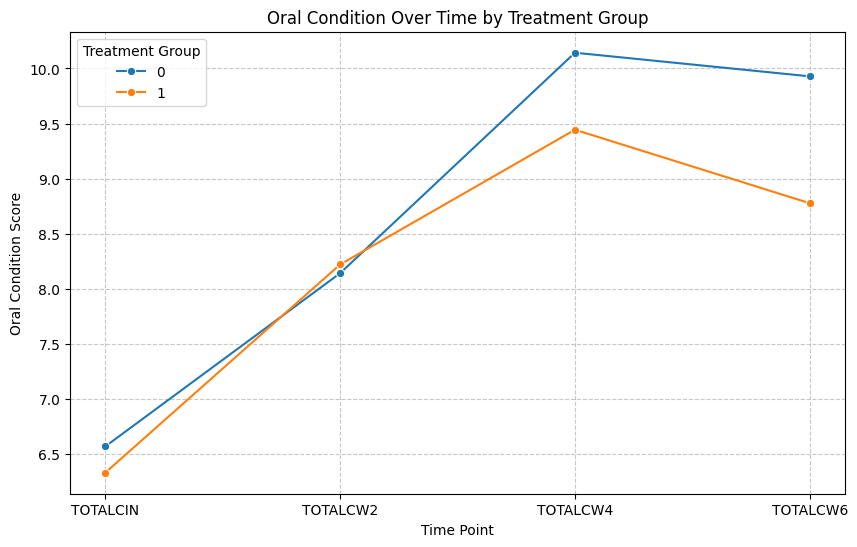

In [ ]:
# Line plot of OralCondition over Time by TRT group (using df_long)
plt.figure(figsize=(10, 6))
sns.lineplot(x='Time', y='OralCondition', hue='TRT', data=df_long, marker='o', errorbar=None)
plt.title('Oral Condition Over Time by Treatment Group')
plt.xlabel('Time Point')
plt.ylabel('Oral Condition Score')
plt.legend(title='Treatment Group')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

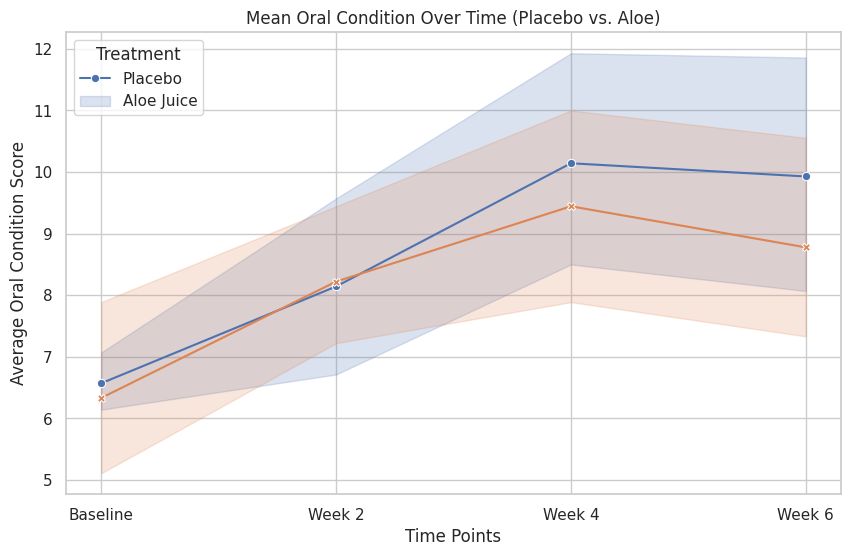

/tmp/ipython-input-2826131282.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_final, x='STAGE', y='TOTALCW6', palette='viridis')


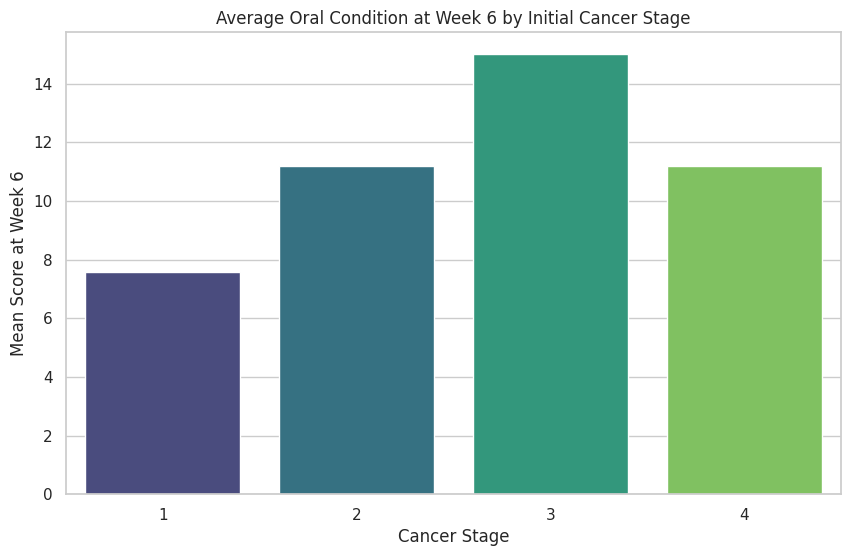

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data: Reshape to "Long Format" for plotting
df_long = pd.melt(df, id_vars=['ID', 'TRT', 'STAGE'],
                  value_vars=['TOTALCIN', 'TOTALCW2', 'TOTALCW4', 'TOTALCW6'],
                  var_name='Time', value_name='OralCondition')

# Map technical column names to readable labels
time_map = {'TOTALCIN': 'Baseline', 'TOTALCW2': 'Week 2',
            'TOTALCW4': 'Week 4', 'TOTALCW6': 'Week 6'}
df_long['Time'] = df_long['Time'].map(time_map)

# Set the visual style
sns.set(style='whitegrid')

# --- PLOT 1: Profile Plot (Trends over Time) ---
# This shows the average path for both groups.
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_long, x='Time', y='OralCondition', hue='TRT',
             style='TRT', markers=True, dashes=False)
plt.title('Mean Oral Condition Over Time (Placebo vs. Aloe)')
plt.ylabel('Average Oral Condition Score')
plt.xlabel('Time Points')
plt.legend(title='Treatment', labels=['Placebo', 'Aloe Juice'])
plt.savefig('profile_plot.png')
plt.show()

# --- PLOT 2: Impact of Cancer Stage ---
# Since STAGE was significant (p = 0.0134), we visualize its effect on the final outcome.
avg_final = df.groupby('STAGE')['TOTALCW6'].mean().reset_index().sort_values('STAGE')
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_final, x='STAGE', y='TOTALCW6', palette='viridis')
plt.title('Average Oral Condition at Week 6 by Initial Cancer Stage')
plt.ylabel('Mean Score at Week 6')
plt.xlabel('Cancer Stage')
plt.savefig('stage_impact.png')
plt.show()